## Imports

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay 
import pandas as pd
from sklearn.utils import shuffle
from sklearn.model_selection import cross_val_score, cross_val_predict, GridSearchCV
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

## Preparing the data

In [22]:
def numeric_columns(df):
    numeric_cols = []
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            numeric_cols.append(col)
    return numeric_cols
# Load dataset
df = pd.read_csv("12 features - no imp.csv")

# Use function to extract numeric columns
numeric_cols = numeric_columns(df)
# print(df_num.shape)
# print(df_num.columns)
# print(df_num['MHW_count'].value_counts())

# Create a copy of the DataFrame
df_numeric = df[numeric_cols].copy()

# Now you can safely modify df_numeric
#df_numeric['mhw_count'] = df_numeric['mhw_count'].astype(str)

df_numeric.loc[df_numeric['mhw_count'].isin([2, 3]), 'mhw_count'] = 2


print(df_numeric['mhw_count'].value_counts())

# Shuffle the DataFrame
shuffled_df_numeric = shuffle(df_numeric, random_state=42)

# Separate features (X) and labels (y) after shuffling
X = shuffled_df_numeric.drop(['mhw_count'], axis=1)
y = shuffled_df_numeric['mhw_count']
X.shape, y.shape

mhw_count
0    3245
1     663
2     158
Name: count, dtype: int64


((4066, 11), (4066,))

## Imputing the data with KNN imputer

In [23]:
nan = np.nan
imputer = KNNImputer(n_neighbors=9, weights="uniform")
imputed = imputer.fit_transform(shuffled_df_numeric)
imputed

array([[1.16472410e-02, 1.06159400e-03, 6.47922000e-03, ...,
        2.45140000e-01, 2.66866322e+01, 0.00000000e+00],
       [1.94212750e-02, 1.49657680e-02, 3.68460630e-02, ...,
        1.67470000e-01, 2.71593145e+01, 0.00000000e+00],
       [1.25061840e-02, 6.80332600e-03, 5.80618200e-03, ...,
        2.00030000e+00, 2.42007933e+01, 0.00000000e+00],
       ...,
       [1.22449710e-02, 6.51764000e-04, 2.28916900e-03, ...,
        2.82200000e-01, 2.97677605e+01, 1.00000000e+00],
       [1.41993290e-02, 9.69287700e-03, 2.57246890e-02, ...,
        1.07768667e+00, 4.30126488e+00, 0.00000000e+00],
       [1.34359670e-02, 5.13751800e-03, 2.38127290e-02, ...,
        4.40630000e-01, 1.76445453e+01, 0.00000000e+00]])

In [24]:
imputed_df = pd.DataFrame(imputed, columns = shuffled_df_numeric.columns)
imputed_df

,ammonium,ammonium std,nitrite,nitrite std,nitrate,iron,nitrate std,radiation 8.1,radiation 30,sea surface temp grad,sea surface temp,mhw_count
0,0.011647,0.001062,0.006479,0.001361,4.039602,0.000004,1.021912,46.347424,45.408386,0.245140,26.686632,0.0
1,0.019421,0.014966,0.036846,0.047819,5.954987,0.000003,1.244382,50.930030,54.287350,0.167470,27.159315,0.0
2,0.012506,0.006803,0.005806,0.004141,0.003165,0.000805,0.002556,52.996185,53.979880,2.000300,24.200793,0.0
3,0.040871,0.012805,0.175246,0.095507,11.336968,0.000004,1.000068,40.447495,43.392790,2.105800,18.466765,0.0
4,0.025083,0.011750,0.054778,0.047893,6.231764,0.000002,0.853389,46.940914,45.790096,0.094916,26.730190,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
4061,0.012845,0.000930,0.029691,0.004530,0.012457,0.001244,0.004551,47.209393,43.349780,0.255560,23.675053,1.0
4062,0.012506,0.006803,0.005806,0.004141,0.003165,0.000805,0.002556,52.275124,54.200054,2.000300,24.192727,0.0
4063,0.012245,0.000652,0.002289,0.000248,0.014058,0.001074,0.004599,41.299805,41.682808,0.282200,29.767761,1.0
4064,0.014199,0.009693,0.025725,0.011551,8.367322,0.000990,3.924304,30.019270,30.199345,1.077687,4.301265,0.0


In [25]:
# Shuffle the DataFrame
shuffled_imp = shuffle(imputed_df, random_state=42)

# Separate features (X) and labels (y) after shuffling
X_imp = shuffled_imp.drop(['mhw_count'], axis=1)
y_imp = shuffled_imp['mhw_count']

## First SVM Clf

cross validation scores SVM: [0.78132678 0.78474785 0.73923739 0.73677737 0.75768758]
0.7600 accuracy with a standard deviation of 0.0202
Accuracy: 76.66%
SVM               precision    recall  f1-score   support

         0.0       0.99      0.79      0.88       650
         1.0       0.49      0.60      0.54       133
         2.0       0.22      0.94      0.36        31

    accuracy                           0.77       814
   macro avg       0.57      0.78      0.59       814
weighted avg       0.88      0.77      0.80       814

SVM <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000001B5CED37220>


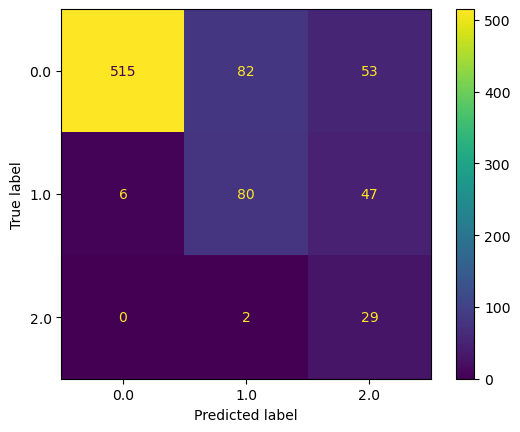

In [26]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_imp, y_imp, stratify = y_imp, test_size=0.2, random_state=42)
# Initialize the XGBClassifier
clf = SVC(class_weight = 'balanced', random_state = 42) 
model = Pipeline(
    steps=[("scaler", StandardScaler()), ("SVM", clf)]
)
# Train the model
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)
# Evaluate the model
cross_val_scores = cross_val_score(model, X_imp, y_imp, cv=5)
print('cross validation scores SVM:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print('SVM', classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
#print('SVM', cm)
print('SVM', ConfusionMatrixDisplay.from_estimator(model, X_test, y_test))

## Grid search SVM

In [27]:
param_grid = [
     {'C': [1, 1.5, 2, 5],
      'class_weight': ['balanced', None],
      'gamma': ['scale', 'auto']
     }
]

grid = GridSearchCV(clf, param_grid, cv = 5, scoring = 'accuracy', verbose = 1)
model_grid = grid.fit(X_train, y_train)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))

Fitting 5 folds for each of 16 candidates, totalling 80 fits
the best score was 0.9541864587025877
the best parameters were {'C': 5, 'class_weight': None, 'gamma': 'auto'}


In [30]:
param_grid = [
     {'C': [3, 4, 5, 6, 7],
      'gamma': ['auto'],
      'class_weight': [None]
     }
]

grid = GridSearchCV(clf, param_grid, cv = 5, scoring = 'accuracy', verbose = 2)
model_grid = grid.fit(X_train, y_train)
print('the best score was', str(model_grid.best_score_))
print('the best parameters were', str(model_grid.best_params_))
pd.DataFrame(model_grid.cv_results_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
[CV] END .................C=3, class_weight=None, gamma=auto; total time=   0.3s
[CV] END .................C=3, class_weight=None, gamma=auto; total time=   0.3s
[CV] END .................C=3, class_weight=None, gamma=auto; total time=   0.2s
[CV] END .................C=3, class_weight=None, gamma=auto; total time=   0.3s
[CV] END .................C=3, class_weight=None, gamma=auto; total time=   0.3s
[CV] END .................C=4, class_weight=None, gamma=auto; total time=   0.2s
[CV] END .................C=4, class_weight=None, gamma=auto; total time=   0.3s
[CV] END .................C=4, class_weight=None, gamma=auto; total time=   0.2s
[CV] END .................C=4, class_weight=None, gamma=auto; total time=   0.2s
[CV] END .................C=4, class_weight=None, gamma=auto; total time=   0.3s
[CV] END .................C=5, class_weight=None, gamma=auto; total time=   0.2s
[CV] END .................C=5, class_weight=None,

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_class_weight,param_gamma,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.285103,0.008189,0.081975,0.006613,3,None,auto,"{'C': 3, 'class_weight': None, 'gamma': 'auto'}",0.941628,0.949309,0.970769,0.944615,0.956923,0.952649,0.010428,5
1,0.283060,0.016106,0.072172,0.009284,4,None,auto,"{'C': 4, 'class_weight': None, 'gamma': 'auto'}",0.941628,0.949309,0.970769,0.943077,0.960000,0.952957,0.011010,4
2,0.271657,0.026282,0.076361,0.004911,5,None,auto,"{'C': 5, 'class_weight': None, 'gamma': 'auto'}",0.941628,0.952381,0.973846,0.944615,0.958462,0.954186,0.011466,2
3,0.256771,0.029566,0.072765,0.006522,6,None,auto,"{'C': 6, 'class_weight': None, 'gamma': 'auto'}",0.938556,0.952381,0.973846,0.949231,0.958462,0.954495,0.011631,1
4,0.278579,0.050573,0.089811,0.019218,7,None,auto,"{'C': 7, 'class_weight': None, 'gamma': 'auto'}",0.940092,0.952381,0.970769,0.946154,0.958462,0.953572,0.010562,3


cross validation scores: [0.91523342 0.90528905 0.90282903 0.90528905 0.89544895]
0.9048 accuracy with a standard deviation of 0.0063
Accuracy: 91.77%
              precision    recall  f1-score   support

         0.0       0.95      0.98      0.96       650
         1.0       0.77      0.72      0.75       133
         2.0       0.78      0.45      0.57        31

    accuracy                           0.92       814
   macro avg       0.83      0.72      0.76       814
weighted avg       0.91      0.92      0.91       814

[[637  13   0]
 [ 33  96   4]
 [  2  15  14]]


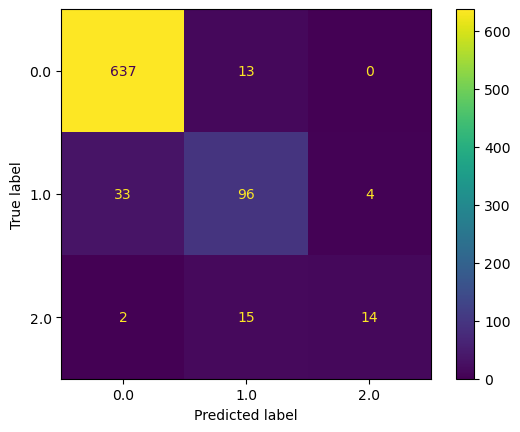

In [31]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_imp, y_imp, stratify = y_imp, test_size=0.2, random_state=42)
# Initialize the XGBClassifier
clf = SVC(C = 6, gamma = 'auto', class_weight = None, random_state = 42) 
model = Pipeline(
    steps=[("scaler", StandardScaler()), ("SVM", clf)]
)
# Train the model
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)
# Evaluate the model
cross_val_scores = cross_val_score(model, X_imp, y_imp, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print(cm)
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

In [16]:
nan = np.nan
imputer = KNNImputer()
imputed = imputer.fit_transform(shuffled_df_numeric)
imputed_df = pd.DataFrame(imputed, columns = shuffled_df_numeric.columns)

# Shuffle the DataFrame
shuffled_imp = shuffle(imputed_df, random_state=42)

# Separate features (X) and labels (y) after shuffling
X_imp = shuffled_imp.drop(['mhw_count'], axis=1)
y_imp = shuffled_imp['mhw_count']

X_imp.shape

(4066, 11)

cross validation scores SVM: [0.77518428 0.78474785 0.73554736 0.74169742 0.74907749]
0.7573 accuracy with a standard deviation of 0.0193
Accuracy: 76.29%
SVM               precision    recall  f1-score   support

         0.0       0.99      0.79      0.88       650
         1.0       0.48      0.60      0.53       133
         2.0       0.22      0.94      0.36        31

    accuracy                           0.76       814
   macro avg       0.56      0.77      0.59       814
weighted avg       0.88      0.76      0.80       814

SVM <sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay object at 0x000001B5CC747670>


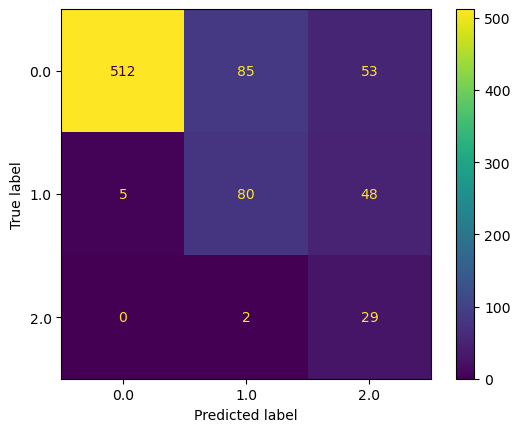

In [21]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_imp, y_imp, stratify = y_imp, test_size=0.2, random_state=42)
# Initialize the XGBClassifier
clf = SVC(class_weight = 'balanced', random_state = 42) 
model = Pipeline(
    steps=[("scaler", StandardScaler()), ("SVM", clf)]
)
# Train the model
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)
# Evaluate the model
cross_val_scores = cross_val_score(model, X_imp, y_imp, cv=5)
print('cross validation scores SVM:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")
print('SVM', classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
#print('SVM', cm)
print('SVM', ConfusionMatrixDisplay.from_estimator(model, X_test, y_test))

In [7]:
from lime.lime_tabular import LimeTabularExplainer
# Create the explainer
explainer = LimeTabularExplainer(X_imp.values, 
                                   feature_names=X_imp.columns, 
                                   class_names=['rings'], 
                                   mode='classification',
                                 discretize_continuous = False,
                                   random_state=42)

In [8]:
# Get explanation for first row
exp = explainer.explain_instance(X_imp.iloc[0], 
                                 clf.predict, 
                                labels=X_imp.columns)

#Display explanation
exp.show_in_notebook(show_table=True)

exp.save_to_file('explanation_1.html')

NotImplementedError: LIME does not currently support classifier models without probability scores. If this conflicts with your use case, please let us know: https://github.com/datascienceinc/lime/issues/16

In [27]:
from sklearn.inspection import DecisionBoundaryDisplay


def plot_training_data_with_decision_boundary(
    kernel='rbf', ax=None, long_title=True, support_vectors=True
):
    # Train the SVC
    clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("SVM", SVC(kernel = 'rbf', class_weight = 'balanced', random_state = 42))]
).fit(X_imp, y_imp)

    # Settings for plotting
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 3))
    x_min, x_max, y_min, y_max = -3, 3, -3, 3
    ax.set(xlim=(x_min, x_max), ylim=(y_min, y_max))

    # Plot decision boundary and margins
    common_params = {"estimator": clf, "X": X_imp, "ax": ax}
    DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method="predict",
        plot_method="pcolormesh",
        alpha=0.3,
    )
    DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method="decision_function",
        plot_method="contour",
        levels=[-1, 0, 1],
        colors=["k", "k", "k"],
        linestyles=["--", "-", "--"],
    )

    if support_vectors:
        # Plot bigger circles around samples that serve as support vectors
        ax.scatter(
            clf.support_vectors_[:, 0],
            clf.support_vectors_[:, 1],
            s=150,
            facecolors="none",
            edgecolors="k",
        )

    # Plot samples by color and add legend
    ax.scatter(X_imp[:, 0], X_imp[:, 1], c=y_imp, s=30, edgecolors="k")
    ax.legend(*scatter.legend_elements(), loc="upper right", title="Classes")
    if long_title:
        ax.set_title(f" Decision boundaries of {kernel} kernel in SVC")
    else:
        ax.set_title(kernel)

    if ax is None:
        plt.show()